In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from utils import utils_ml 
import numpy as np
import gc
import pickle
import glob
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
import sys

In [2]:
# Class mapping dictionary
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}



# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, 10000) 
    for i in np.arange(num_files)
]).flatten()




Loading labels...


In [3]:
def get_features(num):
    feat_to_per_dict = {}
    feature_percentages = np.logspace(-2, 0, 5)  # From 1% to 100% of features
    feature_counts = np.unique(
        np.clip((feature_percentages * num).astype(int), 1, num)
    )
    feat_to_per_dict = {int(feat): per for feat, per in zip(feature_counts, feature_percentages)}
    return feat_to_per_dict
get_features(75).keys()

dict_keys([1, 2, 7, 23, 75])

In [4]:
# Automatically find the matching file
input_files = np.memmap("full_features_sorted_350000_423_T11T12NoBg.npy", dtype='float32', mode='r', shape=(350000, 423))[::100]
input_files_raw = np.memmap("full_features_sorted_raw_350000_75_T11T12NoBg.npy", dtype='float32', mode='r', shape=(350000, 75))[::100]

In [5]:
c1_acc_raw = np.zeros((5,5))

for cnt1, num in enumerate(get_features(75).keys()):
    for i in range(5):
        path = f"models/catboost_model_T11T12NoBg_{num}_fold{i}_raw.cbm"
        model = CatBoostClassifier()
        model.load_model(path)
        X_arr = input_files_raw[:,:num]
        y_pred = model.predict(X_arr).flatten()
        acc = accuracy_score(y_pred, y_arr_classification[::100].flatten())
        c1_acc_raw[cnt1][i] = acc

c1_acc = np.zeros((5,5))

for cnt1, num in enumerate(get_features(423).keys()):
    for i in range(5):
        path = f"models/catboost_model_T11T12NoBg_{num}_fold{i}.cbm"
        model = CatBoostClassifier()
        model.load_model(path)
        X_arr = input_files[:,:num]
        y_pred = model.predict(X_arr).flatten()
        acc = accuracy_score(y_pred, y_arr_classification[::100].flatten())
        c1_acc[cnt1][i] = acc

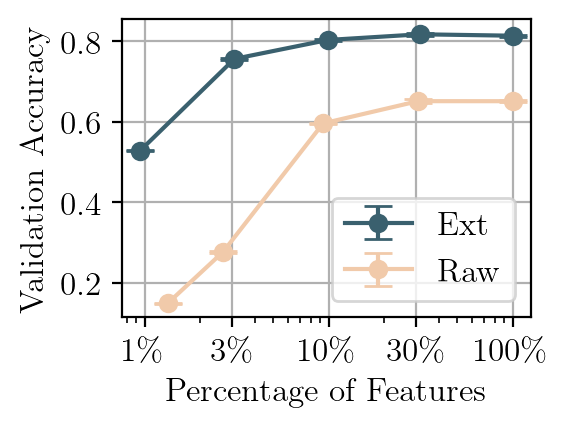

In [ ]:
# Create the plot
plt.figure(figsize=(3, 2.3))
plt.errorbar(100 * np.array(list(get_features(423).keys())) / 423, np.mean(c1_acc,axis=1), yerr=np.std(c1_acc,axis=1), fmt='-o', capsize=5,label="Ext",c="#3a606e")
plt.errorbar(100 * np.array(list(get_features(75).keys())) / 75, np.mean(c1_acc_raw,axis=1), yerr=np.std(c1_acc,axis=1), fmt='-o', capsize=5,label="Raw",c="#f1caaa")
plt.xscale('log')
plt.xticks([1, 3, 10, 30, 100], labels=["1\%", "3\%", "10\%", "30\%", "100\%"])
plt.xlabel("Percentage of Features")
plt.ylabel("Validation Accuracy")
# plt.title("Effect of Feature Count on Accuracy")
plt.grid(True)
# plt.ylim(0,0.6)
plt.tight_layout()
plt.legend()
plt.savefig("feature_selec.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()